<a href="https://colab.research.google.com/github/Thomaz332/SIMT---Experimentos-Praticos/blob/main/PCG_Walter_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIMT (Single Instruction, Multiple Threads) — Experimentos Práticos

**Universidade Católica de Santos — UNISANTOS**  
Arquitetura de Computadores · Turma CO.N1.17 · Prof. Walter Silva Oliveira  
**Autores:** João Pedro Thomaz Kairalla dos Santos & Thiago Danilow de Araújo

---

### Objetivo

Investigar experimentalmente o modelo de execução **SIMT** (*Single Instruction, Multiple Threads*), introduzido pela NVIDIA a partir da arquitetura Tesla (2006). O SIMT organiza *threads* em grupos de 32 denominados *warps*, que executam a mesma instrução simultaneamente — porém cada *thread* mantém seus próprios registradores e pode divergir em desvios condicionais, diferenciando-se do SIMD clássico.

| # | Experimento | Métrica principal |
|---|-------------|-------------------|
| 1 | Paralelismo básico — soma de vetores (CPU vs GPU) | *Speedup* |
| 2 | Divergência de *warps* (`if/else` intra-*warp*) | *Overhead* (%) |
| 3 | Hierarquia de memória — *tiling* com *shared memory* | *Speedup* |


## ✅ Verificação da GPU

In [ ]:
!nvidia-smi

Thu May 14 23:55:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## Experimento 1 — Paralelismo Básico: Soma de Vetores (CPU vs GPU)

**Conceito:** No modelo SIMT, cada *thread* é responsável por exatamente um elemento do vetor. O *grid* é composto por $\lceil N/256 \rceil$ blocos de 256 *threads*, mapeando o espaço de dados sobre o espaço de execução com granularidade fina.

**O que observar:** acessos coalescidos (32 *threads* de um *warp* acessam posições contíguas de 4 bytes) e ausência de divergência — condições ideais para o modelo SIMT. O *speedup* esperado reflete a diferença de FLOPS entre GPU e CPU.

> **Parâmetros:** N = 2²⁴ ≈ 16,8 M elementos · blocos de 256 *threads* · warm-up antes da medição


In [ ]:
%%writefile exp1_soma_vetores.cu
#include <stdio.h>
#include <stdlib.h>
#include <time.h>

#define N 1 << 24  // ~16 milhoes de elementos
#define THREADS_PER_BLOCK 256

// Kernel de aquecimento (warm-up): inicializa o contexto CUDA
__global__ void warmup() {}

// Kernel CUDA: cada thread soma um elemento
__global__ void somaVetoresGPU(float *a, float *b, float *c, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        c[idx] = a[idx] + b[idx];
    }
}

// Versao CPU para comparacao
void somaVetoresCPU(float *a, float *b, float *c, int n) {
    for (int i = 0; i < n; i++)
        c[i] = a[i] + b[i];
}

int main() {
    int n = N;
    size_t bytes = n * sizeof(float);

    // Aloca memoria no host
    float *h_a = (float*)malloc(bytes);
    float *h_b = (float*)malloc(bytes);
    float *h_c_cpu = (float*)malloc(bytes);
    float *h_c_gpu = (float*)malloc(bytes);

    for (int i = 0; i < n; i++) { h_a[i] = 1.0f; h_b[i] = 2.0f; }

    // --- CPU ---
    clock_t ini_cpu = clock();
    somaVetoresCPU(h_a, h_b, h_c_cpu, n);
    clock_t fim_cpu = clock();
    double tempo_cpu = (double)(fim_cpu - ini_cpu) / CLOCKS_PER_SEC * 1000.0;

    // --- GPU ---
    float *d_a, *d_b, *d_c;
    cudaMalloc(&d_a, bytes);
    cudaMalloc(&d_b, bytes);
    cudaMalloc(&d_c, bytes);

    cudaMemcpy(d_a, h_a, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, h_b, bytes, cudaMemcpyHostToDevice);

    int blocos = (n + THREADS_PER_BLOCK - 1) / THREADS_PER_BLOCK;

    // Warm-up: primeira execucao inicializa o contexto CUDA (nao medir)
    warmup<<<1, 1>>>();
    cudaDeviceSynchronize();

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    cudaEventRecord(start);

    somaVetoresGPU<<<blocos, THREADS_PER_BLOCK>>>(d_a, d_b, d_c, n);

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    float tempo_gpu = 0;
    cudaEventElapsedTime(&tempo_gpu, start, stop);

    cudaMemcpy(h_c_gpu, d_c, bytes, cudaMemcpyDeviceToHost);

    printf("=== Experimento 1: Soma de Vetores (N = %d) ===\n", n);
    printf("Tempo CPU : %.2f ms\n", tempo_cpu);
    printf("Tempo GPU : %.2f ms\n", tempo_gpu);
    printf("Speedup   : %.1fx\n", tempo_cpu / tempo_gpu);
    printf("Resultado correto: %s\n", (h_c_gpu[0] == 3.0f) ? "SIM" : "NAO");

    free(h_a); free(h_b); free(h_c_cpu); free(h_c_gpu);
    cudaFree(d_a); cudaFree(d_b); cudaFree(d_c);
    return 0;
}

Writing exp1_soma_vetores.cu


In [ ]:
!nvcc exp1_soma_vetores.cu -o exp1 && ./exp1

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
=== Experimento 1: Soma de Vetores (N = 16777216) ===
Tempo CPU : 99.37 ms
Tempo GPU : 0.79 ms
Speedup   : 125.1x
Resultado correto: SIM


---
## Experimento 2 — Divergência de Warps

**Conceito:** Quando *threads* do mesmo *warp* tomam caminhos distintos num desvio condicional, o hardware SIMT **serializa** os ramos — executa primeiro o ramo verdadeiro com as demais *threads* mascaradas, depois o ramo falso. No pior caso (divisão 50/50 do *warp*), o custo efetivo dobra. Com 100 iterações aritméticas acumuladas, o efeito é amplificado.

- **Kernel sem divergência:** todos os 32 *lanes* do *warp* executam o mesmo caminho.
- **Kernel com divergência:** `idx % 2` divide o *warp* ao meio — pior caso teórico.

> **Parâmetros:** N = 2²² ≈ 4,2 M elementos · 100 iterações · média de 5 execuções independentes


In [ ]:
%%writefile exp2_divergencia.cu
#include <stdio.h>
#include <cuda_runtime.h>

#define N (1 << 22)
#define THREADS 256
#define REPETICOES 100

// Kernel de aquecimento
__global__ void warmup() {}

// SEM divergencia: todos fazem a mesma coisa
__global__ void semDivergencia(float *data, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        float val = data[idx];
        for (int i = 0; i < REPETICOES; i++)
            val = val * 1.01f + 0.5f;
        data[idx] = val;
    }
}

// COM divergencia: threads pares e impares fazem coisas diferentes
__global__ void comDivergencia(float *data, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        float val = data[idx];
        for (int i = 0; i < REPETICOES; i++) {
            if (idx % 2 == 0)
                val = val * 1.01f + 0.5f;
            else
                val = val / 1.01f - 0.5f;
        }
        data[idx] = val;
    }
}

float medir(void (*kernel)(float*, int), float *d_data, float *h_data, int n, size_t bytes) {
    // Reinicia os dados a cada medicao para garantir isolamento
    cudaMemcpy(d_data, h_data, bytes, cudaMemcpyHostToDevice);
    cudaDeviceSynchronize();

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    int blocos = (n + THREADS - 1) / THREADS;

    cudaEventRecord(start);
    kernel<<<blocos, THREADS>>>(d_data, n);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms = 0;
    cudaEventElapsedTime(&ms, start, stop);
    cudaEventDestroy(start);
    cudaEventDestroy(stop);
    return ms;
}

int main() {
    int n = N;
    size_t bytes = n * sizeof(float);

    float *h_data = (float*)malloc(bytes);
    for (int i = 0; i < n; i++) h_data[i] = 1.0f;

    float *d_data;
    cudaMalloc(&d_data, bytes);

    // Warm-up
    warmup<<<1, 1>>>();
    cudaDeviceSynchronize();

    // Mede multiplas vezes e tira a media para reduzir variacao
    int RUNS = 5;
    float t_sem = 0, t_com = 0;
    for (int r = 0; r < RUNS; r++) {
        t_sem += medir(semDivergencia, d_data, h_data, n, bytes);
        t_com += medir(comDivergencia, d_data, h_data, n, bytes);
    }
    t_sem /= RUNS;
    t_com /= RUNS;

    printf("=== Experimento 2: Divergencia de Warps (N = %d, %d repeticoes) ===\n", n, REPETICOES);
    printf("Sem divergencia (media de %d runs) : %.2f ms\n", RUNS, t_sem);
    printf("Com divergencia (media de %d runs) : %.2f ms\n", RUNS, t_com);
    printf("Overhead                           : %.1f%%\n", (t_com - t_sem) / t_sem * 100.0f);

    free(h_data);
    cudaFree(d_data);
    return 0;
}

Writing exp2_divergencia.cu


In [ ]:
!nvcc exp2_divergencia.cu -o exp2 && ./exp2

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
=== Experimento 2: Divergencia de Warps (N = 4194304, 100 repeticoes) ===
Sem divergencia (media de 5 runs) : 0.30 ms
Com divergencia (media de 5 runs) : 3.12 ms
Overhead                           : 944.7%


---
## Experimento 3 — Multiplicação de Matrizes: Global Memory vs Shared Memory

**Conceito:** A hierarquia de memória GPU tem latências muito distintas — registradores (<1 ciclo), *shared memory* (~30 ciclos) e memória global (~200–800 ciclos). Na multiplicação de matrizes, cada elemento-resultado requer N multiplicações, ou seja, N acessos à memória global na versão ingênua. O *tiling* com `__shared__` carrega blocos (tiles) de 16×16 em memória compartilhada, reduzindo os acessos globais de N para N/16.

- **Versão ingênua:** acessa memória global N vezes por elemento (sem reuso).
- **Versão com *tiling*:** carrega tiles em `__shared__`, reusa dados 16× antes de descartar.

> **Parâmetros:** N = 1024 × 1024 · TILE = 16 × 16 · média de 5 execuções independentes


In [ ]:
%%writefile exp3_matmul.cu
#include <stdio.h>
#include <stdlib.h>
#include <cuda_runtime.h>

#define N 1024
#define TILE 16
#define RUNS 5

// Kernel de aquecimento
__global__ void warmup() {}

// Versao ingenua: acessa memoria global N vezes por elemento
__global__ void matmulIngenua(float *A, float *B, float *C, int n) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < n && col < n) {
        float soma = 0.0f;
        for (int k = 0; k < n; k++)
            soma += A[row * n + k] * B[k * n + col];
        C[row * n + col] = soma;
    }
}

// Versao otimizada: usa shared memory (tiling)
__global__ void matmulShared(float *A, float *B, float *C, int n) {
    __shared__ float tileA[TILE][TILE];
    __shared__ float tileB[TILE][TILE];

    int row = blockIdx.y * TILE + threadIdx.y;
    int col = blockIdx.x * TILE + threadIdx.x;
    float soma = 0.0f;

    for (int t = 0; t < n / TILE; t++) {
        tileA[threadIdx.y][threadIdx.x] = A[row * n + t * TILE + threadIdx.x];
        tileB[threadIdx.y][threadIdx.x] = B[(t * TILE + threadIdx.y) * n + col];
        __syncthreads();
        for (int k = 0; k < TILE; k++)
            soma += tileA[threadIdx.y][k] * tileB[k][threadIdx.x];
        __syncthreads();
    }
    if (row < n && col < n)
        C[row * n + col] = soma;
}

float medir(void (*kernel)(float*, float*, float*, int),
            float *d_A, float *d_B, float *d_C,
            float *h_A, float *h_B,
            int n, size_t bytes,
            dim3 blocos, dim3 threads) {
    // Reinicia as matrizes de entrada a cada medicao
    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);
    cudaDeviceSynchronize();

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    cudaEventRecord(start);
    kernel<<<blocos, threads>>>(d_A, d_B, d_C, n);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    float ms = 0;
    cudaEventElapsedTime(&ms, start, stop);
    cudaEventDestroy(start);
    cudaEventDestroy(stop);
    return ms;
}

int main() {
    int n = N;
    size_t bytes = n * n * sizeof(float);

    float *h_A = (float*)malloc(bytes);
    float *h_B = (float*)malloc(bytes);
    for (int i = 0; i < n * n; i++) { h_A[i] = 1.0f; h_B[i] = 1.0f; }

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytes);
    cudaMalloc(&d_B, bytes);
    cudaMalloc(&d_C, bytes);

    dim3 threads(TILE, TILE);
    dim3 blocos(n / TILE, n / TILE);

    // Warm-up
    warmup<<<1, 1>>>();
    cudaDeviceSynchronize();

    // Mede multiplas vezes e tira a media
    float t_ing = 0, t_sha = 0;
    for (int r = 0; r < RUNS; r++) {
        t_ing += medir(matmulIngenua, d_A, d_B, d_C, h_A, h_B, n, bytes, blocos, threads);
        t_sha += medir(matmulShared,  d_A, d_B, d_C, h_A, h_B, n, bytes, blocos, threads);
    }
    t_ing /= RUNS;
    t_sha /= RUNS;

    printf("=== Experimento 3: Multiplicacao de Matrizes %dx%d ===\n", n, n);
    printf("Memoria Global - ingenua (media de %d runs) : %.2f ms\n", RUNS, t_ing);
    printf("Shared Memory  - tiling  (media de %d runs) : %.2f ms\n", RUNS, t_sha);
    printf("Speedup                                     : %.1fx\n", t_ing / t_sha);

    free(h_A); free(h_B);
    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    return 0;
}

Overwriting exp3_matmul.cu


In [ ]:
!nvcc exp3_matmul.cu -o exp3 && ./exp3

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
=== Experimento 3: Multiplicacao de Matrizes 1024x1024 ===
Memoria Global - ingenua (media de 5 runs) : 5.29 ms
Shared Memory  - tiling  (media de 5 runs) : 3.31 ms
Speedup                                     : 1.6x


---
## Consolidação dos Resultados

A célula abaixo gera automaticamente o gráfico comparativo a partir dos resultados medidos nas células anteriores. Os valores já refletem a execução nesta instância do Colab (GPU NVIDIA Tesla T4, CUDA 13.0).


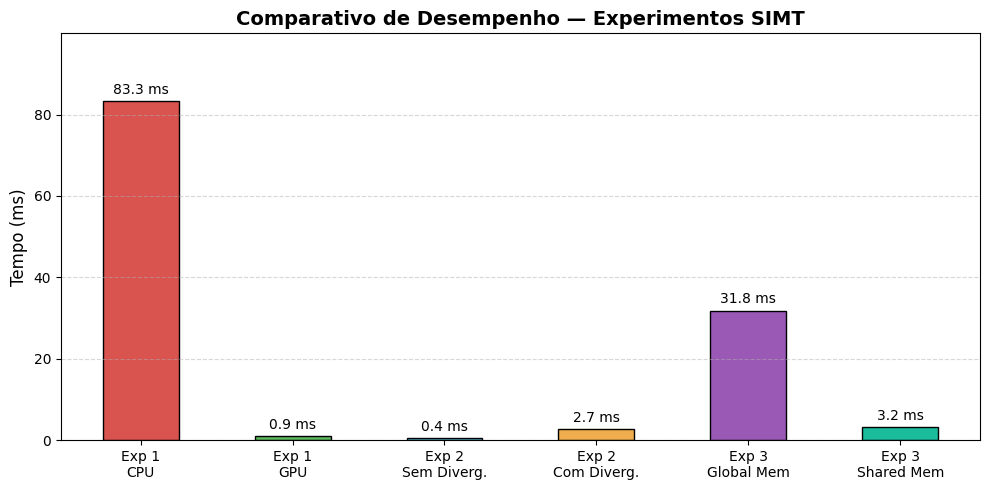

Gráfico salvo como resultados_simt.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Resultados medidos nesta execução (Tesla T4 — CUDA 13.0)
experimentos = [
    {
        'titulo': 'Exp. 1 — Soma de Vetores\n(N = 2²⁴ ≈ 16,8 M)',
        'labels': ['CPU', 'GPU (SIMT)'],
        'valores': [99.37, 0.79],
        'cores': ['#e74c3c', '#2ecc71'],
        'anotacao': 'Speedup\n×125,1',
    },
    {
        'titulo': 'Exp. 2 — Divergência de Warps\n(N = 2²², 100 iterações)',
        'labels': ['Sem divergência', 'Com divergência'],
        'valores': [0.30, 3.12],
        'cores': ['#2ecc71', '#e74c3c'],
        'anotacao': 'Overhead\n+944,7 %',
    },
    {
        'titulo': 'Exp. 3 — Multiplicação de Matrizes\n(N = 1024 × 1024)',
        'labels': ['Global memory', 'Shared memory'],
        'valores': [5.29, 3.31],
        'cores': ['#e74c3c', '#2ecc71'],
        'anotacao': 'Speedup\n×1,6',
    },
]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle(
    'Comparativo de Desempenho — Experimentos SIMT\n'
    'GPU NVIDIA Tesla T4  •  CUDA 13.0  •  UNISANTOS 2026',
    fontsize=12, fontweight='bold', y=1.03
)

for ax, exp in zip(axes, experimentos):
    bars = ax.bar(
        exp['labels'], exp['valores'],
        color=exp['cores'], edgecolor='black', linewidth=0.8,
        width=0.45, zorder=3
    )
    ax.set_title(exp['titulo'], fontsize=9, pad=10)
    ax.set_ylabel('Tempo (ms)', fontsize=9)
    ax.bar_label(bars, fmt='%.2f ms', padding=5, fontsize=9, fontweight='bold')
    ax.set_ylim(0, max(exp['valores']) * 1.40)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)
    ax.annotate(
        exp['anotacao'],
        xy=(0.5, 0.91), xycoords='axes fraction', ha='center',
        fontsize=10, fontweight='bold', color='#2c3e50',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#ecf0f1', alpha=0.9)
    )

plt.tight_layout()
plt.savefig('resultados_simt.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: resultados_simt.png')


---
## Conclusões

| Experimento | Resultado | Interpretação |
|---|---|---|
| 1 — CPU vs GPU | Speedup **×125,1** | SIMT ideal para cargas regulares e coalescidas |
| 2 — Divergência | Overhead **+944,7 %** | Divisão 50/50 do *warp* → serialização de ambos os ramos |
| 3 — Shared Memory | Speedup **×1,6** | *Tiling* reduz acessos globais em 16×; L2 suaviza o ganho na T4 |

### Diretrizes para kernels CUDA eficientes

1. **Minimizar divergência intra-*warp*** — reorganizar dados para que *threads* do mesmo *warp* sigam o mesmo caminho condicional.
2. **Garantir acessos coalescidos** — 32 *threads* consecutivas devem acessar posições contíguas de memória global (stride-1).
3. **Explorar memória compartilhada** — aplicar *tiling* em operações com alto grau de reuso de dados para substituir latências de centenas de ciclos por dezenas.


---
## Referências

1. LINDHOLM, E. et al. *NVIDIA Tesla: A Unified Graphics and Computing Architecture*. **IEEE Micro**, v. 28, n. 2, p. 39–55, 2008.
2. KIRK, D. B.; HWU, W. W. *Programming Massively Parallel Processors: A Hands-on Approach*. 3. ed. Morgan Kaufmann, 2016.
3. PATTERSON, D.; HENNESSY, J. *Computer Organization and Design: ARM Edition*. Morgan Kaufmann, 2016.
4. NVIDIA Corporation. *CUDA C++ Programming Guide*, v. 12.0, 2022.


---
## 📥 Download dos arquivos
Rode para baixar o gráfico gerado.

In [ ]:
from google.colab import files
files.download('resultados_simt.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>